In [ ]:
import gymnasium as gym
import numpy as np
import cv2
import ale_py

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecTransposeImage, VecFrameStack, SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.atari_wrappers import FireResetEnv

from stable_baselines3.common.env_util import make_vec_env

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import glob
from datetime import datetime

In [ ]:
gym.register_envs(ale_py)

In [ ]:
log_dir = "./logs_breakout/"
os.makedirs(log_dir, exist_ok=True)

In [ ]:
class WhitePatchBreakout(gym.Wrapper):
    def __init__(self, env, apply_patch=False, region=(20, 40, 30, 30)):
        super().__init__(env)
        self.apply_patch = apply_patch
        self.x, self.y, self.w, self.h = region

    def _paint_patch(self, img):
        if not self.apply_patch:
            return img
        
        # Copia para não alterar o buffer original inadvertidamente
        img = img.copy()
        
        # Detecta dimensões (pode ser 84x84 ou a resolução nativa no render)
        H, W = img.shape[:2]
        
        x, y, w, h = self.x, self.y, self.w, self.h
        
        # Garante que o desenho não exceda as bordas
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            # Pinta de branco (255). Funciona tanto para RGB quanto Grayscale se ajustado
            img[y:y_end, x:x_end] = 255
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._paint_patch(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._paint_patch(obs), reward, terminated, truncated, info

    def render(self):
        # Mágica para o vídeo: Pega o render original e aplica a mancha nele
        img = self.env.render()
        return self._paint_patch(img)

In [ ]:
class BlurBreakout(gym.Wrapper):
    def __init__(self, env, apply_blur=False, region=(20, 40, 30, 30), ksize=21):
        super().__init__(env)
        self.apply_blur = apply_blur
        self.x, self.y, self.w, self.h = region
        self.ksize = ksize if ksize % 2 == 1 else ksize + 1

    def _apply_blur(self, img):
        if not self.apply_blur:
            return img
        
        img = img.copy()
        H, W = img.shape[:2]
        x, y, w, h = self.x, self.y, self.w, self.h
        
        y_end = min(y + h, H)
        x_end = min(x + w, W)
        
        if y < y_end and x < x_end:
            roi = img[y:y_end, x:x_end]
            # Aplica Gaussian Blur na região de interesse
            blurred_roi = cv2.GaussianBlur(roi, (self.ksize, self.ksize), 0)
            img[y:y_end, x:x_end] = blurred_roi
            
        return img

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._apply_blur(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._apply_blur(obs), reward, terminated, truncated, info
    
    def render(self):
        img = self.env.render()
        return self._apply_blur(img)

In [ ]:
class GrayscaleWrapper(gym.Wrapper):
    def __init__(self, env):
        super().__init__(env)
        # Força explicitamente o shape (H, W, 1) para compatibilidade com SB3
        old_shape = self.observation_space.shape
        self.observation_space = gym.spaces.Box(
            low=0, high=255, shape=(old_shape[0], old_shape[1], 1), dtype=np.uint8
        )

    def _convert(self, obs):
        # Se for RGB (3 canais), converte para Gray e mantém dimensão extra
        if obs.ndim == 3 and obs.shape[2] == 3:
            return cv2.cvtColor(obs, cv2.COLOR_RGB2GRAY)[:, :, None]
        return obs

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        return self._convert(obs), info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        return self._convert(obs), reward, terminated, truncated, info

In [ ]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino.
    Agora gera um arquivo monitor com TIMESTAMP para não sobrescrever os anteriores.
    Ex: ./logs/monitor_20231027_153000.csv
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
    
    # Gera o timestamp UMA VEZ para este ambiente
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor (AGORA COM TIMESTAMP NO NOME)
        if log_dir:
            # Cria o caminho: ./logs/monitor_20231123_220000
            # O SB3 adiciona .csv automaticamente na maioria das versões
            filename = os.path.join(log_dir, f"monitor_{timestamp}")
            env = Monitor(env, filename)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [ ]:
def make_training_env(with_blur=False, change='white_patch', log_dir="./logs/"):
    """
    Cria o ambiente de treino mantendo a consistência exata com o ambiente de avaliação.
    Parâmetros renomeados para bater com sua chamada: with_blur, change.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    def _init():
        # 1. Base Environment
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        
        # 2. Fire Reset
        env = FireResetEnv(env)
        
        # 3. Resize PRIMEIRO (Para 84x84)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # 4. Aplica a Modificação (Blur ou White Patch)
        if change == 'white_patch':
            # Usa sua classe com apply_patch=with_blur
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # 5. Grayscale (Transforma em H, W, 1)
        env = GrayscaleWrapper(env)
        
        # 6. Monitor
        if log_dir:
            env = Monitor(env, log_dir)
            
        return env

    # 7. Vetorização (SB3)
    env = DummyVecEnv([_init])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [ ]:
def make_ppo_env(n_envs=8, with_blur=False, change='white_patch', log_dir="./logs_ppo/"):
    """
    Cria N ambientes rodando em paralelo (Multiprocessamento).
    Isso acelera drasticamente a coleta de dados.
    """
    if log_dir:
        os.makedirs(log_dir, exist_ok=True)

    # Função de fábrica para CADA ambiente individual
    def wrapper_maker():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env)
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        # Aplica modificação
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
            
        env = GrayscaleWrapper(env)
        
        # Monitor precisa ser individual para cada processo
        if log_dir:
            env = Monitor(env) 
        return env

    # Cria 8 ambientes rodando em paralelo na CPU
    # Se seu PC for fraco, mude n_envs para 4. Se for forte, 16.
    env = make_vec_env(
        wrapper_maker, 
        n_envs=n_envs, 
        seed=0, 
        vec_env_cls=SubprocVecEnv # Garante processos reais separados
    )
    
    # Empilha e Transpõe as imagens dos 8 ambientes
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)
    
    return env

In [ ]:
log_dir_ppo_clean = "./logs_ppo_patch_clean/"
log_dir_ppo_mancha = "./logs_ppo_patch_mancha/"

In [ ]:
steps = 20_000

In [ ]:
n_envs = 4 
print(f"--- Iniciando {n_envs} Ambientes Paralelos ---")
env_ppo_mancha = make_ppo_env(n_envs=n_envs, with_blur=True, change='white_patch', log_dir=log_dir_ppo_mancha)

# 3. Definir Modelo PPO (Hiperparâmetros otimizados para Atari)
model_ppo_mancha = PPO(
    "CnnPolicy", 
    env_ppo_mancha, 
    verbose=1,
    learning_rate=2.5e-4, 
    n_steps=128,           
    batch_size=256,       
    n_epochs=4,            
    clip_range=0.1,        
    ent_coef=0.01,         
    vf_coef=0.5,
)

# 4. Treinar
print("--- Iniciando Treino PPO (Isso deve ser bem mais rápido em FPS) ---")
model_ppo_mancha.learn(total_timesteps=steps)
model_ppo_mancha.save("ppo_breakout_mancha")
print("Modelo PPO salvo.")
env_ppo_mancha.close()

In [ ]:
print(f"--- Iniciando {n_envs} Ambientes Paralelos ---")
env_ppo_clean = make_ppo_env(n_envs=n_envs, with_blur=False, change='white_patch', log_dir=log_dir_ppo_clean)

# 3. Definir Modelo PPO (Hiperparâmetros otimizados para Atari)
model_ppo_clean = PPO(
    "CnnPolicy", 
    env_ppo_clean, 
    verbose=1,
    learning_rate=2.5e-4, 
    n_steps=128,           
    batch_size=256,       
    n_epochs=4,            
    clip_range=0.1,        
    ent_coef=0.01,         
    vf_coef=0.5,
)

# 4. Treinar
print("--- Iniciando Treino PPO (Isso deve ser bem mais rápido em FPS) ---")
model_ppo_clean.learn(total_timesteps=steps)
model_ppo_clean.save("ppo_breakout_clean")
print("Modelo PPO salvo.")
env_ppo_clean.close()

In [ ]:
def get_latest_log_file(folder):
    """
    Busca na pasta o arquivo monitor*.csv mais recente (baseado na data de modificação).
    """
    # Procura por monitor.csv, monitor_2023....csv, etc.
    search_path = os.path.join(folder, "monitor*.csv")
    files = glob.glob(search_path)
    
    if not files:
        print(f"Aviso: Nenhum arquivo 'monitor*.csv' encontrado em {folder}")
        return None
    
    # Ordena pelo tempo de modificação (o último é o mais recente)
    latest_file = max(files, key=os.path.getmtime)
    print(f"Lendo log mais recente em '{folder}': {os.path.basename(latest_file)}")
    return latest_file

In [ ]:
def plot_comparison(log_dir_1, name_1, log_dir_2, name_2):
    plt.figure(figsize=(12, 6))
    
    # Função interna para ler dados usando o helper
    def read_data(folder):
        file_path = get_latest_log_file(folder)
        if file_path is None:
            return None, None

        df = pd.read_csv(file_path, skiprows=1)
        if df.empty: return None, None
        
        x = df['l'].cumsum() # Steps acumulados
        y = df['r']          # Recompensa
        # Suavização (Média móvel de 100 episódios)
        y_smooth = y.rolling(window=100).mean()
        return x, y_smooth

    # Plota o Primeiro
    x1, y1 = read_data(log_dir_1)
    if x1 is not None:
        plt.plot(x1, y1, label=name_1, color='blue', linewidth=2)

    # Plota o Segundo
    x2, y2 = read_data(log_dir_2)
    if x2 is not None:
        plt.plot(x2, y2, label=name_2, color='red', linewidth=2, linestyle='--')

    plt.xlabel('Timesteps (Passos)')
    plt.ylabel('Recompensa Média (Média Móvel 100 ep)')
    plt.title('Comparação de Performance: Normal vs Oclusão')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Lendo log mais recente em './logs_clean/': monitor.csv
Lendo log mais recente em './logs_patch/': monitor.csv


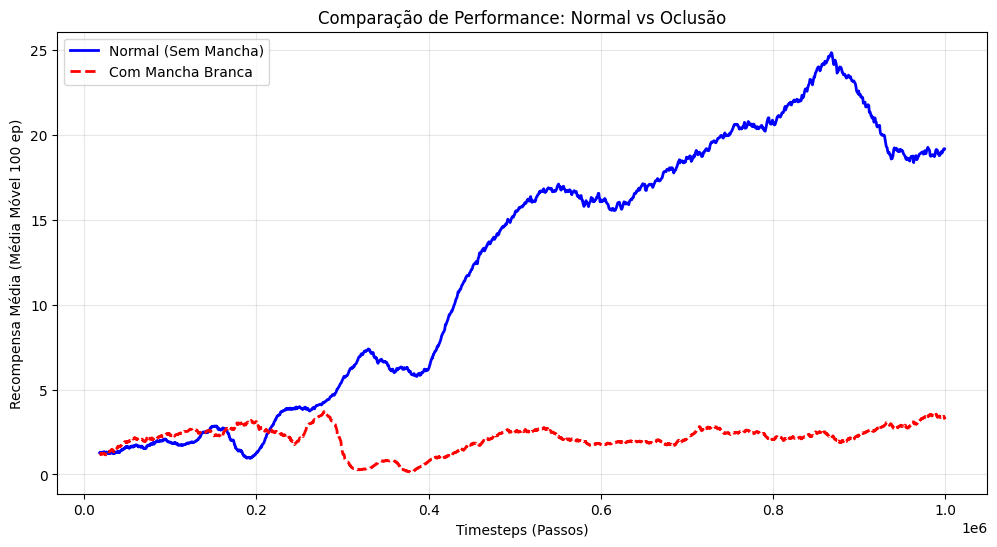

In [ ]:
plot_comparison(
    log_dir_ppo_clean, "PPO Clean", 
    log_dir_ppo_mancha, "PPO Mancha"
)

In [ ]:
def plot_advanced_analysis(log_dir_1, name_1, log_dir_2, name_2):
    
    def read_dataframe(folder):
        file_path = get_latest_log_file(folder)
        if file_path is None:
            return None
        # Pula as duas primeiras linhas (header do SB3)
        try:
            df = pd.read_csv(file_path, skiprows=1)
            return df
        except Exception as e:
            print(f"Erro ao ler {file_path}: {e}")
            return None

    df1 = read_dataframe(log_dir_1)
    df2 = read_dataframe(log_dir_2)

    if df1 is None and df2 is None:
        print("Nenhum dado válido encontrado para plotar.")
        return

    # Cria uma figura com 3 subgráficos (gridspec para layout bonito)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(2, 2)
    
    # --- GRÁFICO 1: RECOMPENSA (Média Móvel) ---
    ax1 = fig.add_subplot(gs[0, :]) # Ocupa a linha inteira superior
    window = 100
    
    if df1 is not None and not df1.empty:
        x1 = df1['l'].cumsum()
        y1 = df1['r'].rolling(window=window).mean()
        ax1.plot(x1, y1, label=f"{name_1}", color='blue')
        std1 = df1['r'].rolling(window=window).std()
        ax1.fill_between(x1, y1-std1, y1+std1, color='blue', alpha=0.1)

    if df2 is not None and not df2.empty:
        x2 = df2['l'].cumsum()
        y2 = df2['r'].rolling(window=window).mean()
        ax1.plot(x2, y2, label=f"{name_2}", color='red', linestyle='--')
        std2 = df2['r'].rolling(window=window).std()
        ax1.fill_between(x2, y2-std2, y2+std2, color='red', alpha=0.1)

    ax1.set_title("1. Curva de Aprendizado (Recompensa Média)")
    ax1.set_ylabel("Pontos no Breakout")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # --- GRÁFICO 2: DURAÇÃO DO EPISÓDIO (Sobrevivência) ---
    ax2 = fig.add_subplot(gs[1, 0])
    
    if df1 is not None and not df1.empty:
        y1_len = df1['l'].rolling(window=window).mean()
        ax2.plot(x1, y1_len, color='blue')

    if df2 is not None and not df2.empty:
        y2_len = df2['l'].rolling(window=window).mean()
        ax2.plot(x2, y2_len, color='red', linestyle='--')
        
    ax2.set_title("2. Sobrevivência (Duração do Jogo)")
    ax2.set_ylabel("Frames por Episódio")
    ax2.set_xlabel("Total Timesteps")
    ax2.grid(True, alpha=0.3)
    
    # --- GRÁFICO 3: VELOCIDADE DE TREINO (FPS Real) ---
    ax3 = fig.add_subplot(gs[1, 1])
    
    if df1 is not None and not df1.empty:
        fps1 = x1.iloc[-1] / df1['t'].iloc[-1]
        ax3.bar(name_1, fps1, color='blue', alpha=0.6)
        ax3.text(name_1, fps1, f"{int(fps1)} FPS", ha='center', va='bottom')

    if df2 is not None and not df2.empty:
        fps2 = x2.iloc[-1] / df2['t'].iloc[-1]
        ax3.bar(name_2, fps2, color='red', alpha=0.6)
        ax3.text(name_2, fps2, f"{int(fps2)} FPS", ha='center', va='bottom')

    ax3.set_title("3. Velocidade de Treinamento (FPS)")
    ax3.set_ylabel("Frames por Segundo")

    plt.tight_layout()
    plt.show()

Lendo log mais recente em './logs_clean/': monitor.csv
Lendo log mais recente em './logs_patch/': monitor.csv


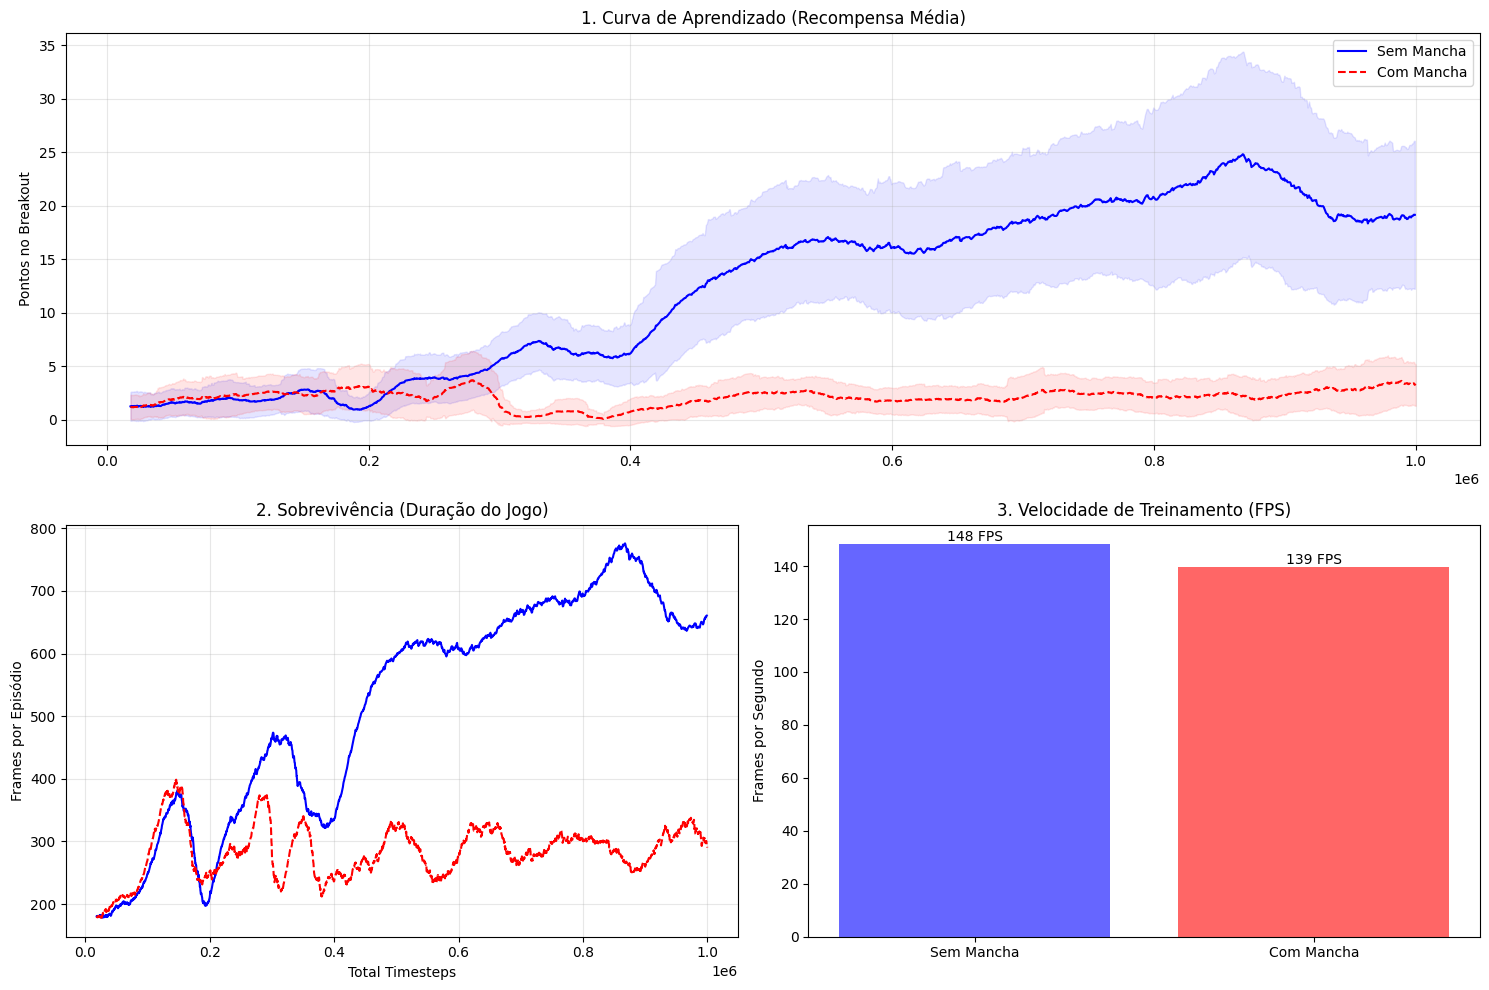

In [ ]:
# Chama a função comparando as pastas que criamos antes
plot_advanced_analysis(
    log_dir_ppo_clean, "PPO Clean", 
    log_dir_ppo_mancha, "PPO Mancha"
)

In [ ]:
def record_video(model, name_prefix, with_blur, change='white_patch', n_episodes=1, max_steps=3000):
    video_folder = "./videos/"
    os.makedirs(video_folder, exist_ok=True)
    
    print(f"--- Gravando {name_prefix} (Max {max_steps} steps) ---")

    # 1. Configura ambiente
    def _create_video_env():
        env = gym.make("ALE/Breakout-v5", render_mode="rgb_array")
        env = FireResetEnv(env) # Start inicial
        env = gym.wrappers.ResizeObservation(env, (84, 84))
        
        if change == 'white_patch':
            env = WhitePatchBreakout(env, apply_patch=with_blur, region=(20, 40, 30, 30))
        elif change == 'blur':
            env = BlurBreakout(env, apply_blur=with_blur, region=(20, 40, 30, 30), ksize=21)
        
        # Grava colorido e com a mancha
        env = gym.wrappers.RecordVideo(
            env, 
            video_folder=video_folder, 
            name_prefix=name_prefix,
            episode_trigger=lambda x: True,
            disable_logger=True
        )
        
        env = GrayscaleWrapper(env)
        return env

    env = DummyVecEnv([_create_video_env])
    env = VecTransposeImage(env)
    env = VecFrameStack(env, n_stack=4)

    obs = env.reset()
    episodes_count = 0
    current_steps = 0
    
    # Rastrear vidas para saber quando apertar FIRE
    last_lives = 5 
    
    try:
        while episodes_count < n_episodes:
            action, _ = model.predict(obs, deterministic=True)
            
            # --- SEGURANÇA 1: Force Fire se perdeu vida ---
            # Precisamos acessar o info interno, mas no step anterior.
            # Como é difícil acessar info antes do step, vamos usar uma heurística:
            # Se o agente ficar 20 steps sem recompensa, tenta FIRE (ação 1)
            
            obs, rewards, done, infos = env.step(action)
            current_steps += 1
            
            # Checa vidas no info
            for info in infos:
                lives = info.get("lives", 0)
                if lives < last_lives:
                    # Perdeu vida! Forçar FIRE no próximo passo seria ideal, 
                    last_lives = lives
                    # Dica: Se o agente for muito ruim, ele pode precisar de ajuda manual aqui
            
            # --- SEGURANÇA 2: Limite de Passos (Corta vídeo infinito) ---
            if current_steps > max_steps:
                print(f"ALERTA: Episódio excedeu {max_steps} passos. Forçando parada.")
                done = [True] # Força reinício
            
            # Verifica fim de episódio real
            for i, d in enumerate(done):
                if d:
                    episodes_count += 1
                    current_steps = 0
                    last_lives = 5
                    # Recupera score se disponível
                    score = infos[i].get('episode', {}).get('r', 0)
                    print(f"Episódio {episodes_count} finalizado | Score: {score}")
                    obs = env.reset() # Garante reset limpo
                    
    except KeyboardInterrupt:
        print("Interrompido.")
    finally:
        env.close()
        print(f"Vídeos salvos em {video_folder}")

In [ ]:
record_video(model_blur, "teste_com_blur", with_blur=True, change = 'white_patch', n_episodes=5)

--- Gravando teste_com_blur (Max 3000 steps) ---
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 1 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 2 finalizado | Score: 0
Episódio 3 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 4 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/


In [ ]:
record_video(model_normal, "teste_sem_blur", with_blur=False, change = 'white_patch', n_episodes=5)

--- Gravando teste_sem_blur (Max 3000 steps) ---
Episódio 1 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 2 finalizado | Score: 0
ALERTA: Episódio excedeu 3000 passos. Forçando parada.
Episódio 3 finalizado | Score: 0
Episódio 4 finalizado | Score: 0
Episódio 5 finalizado | Score: 0
Vídeos salvos em ./videos/
